# Car Price Prediction - Professional Notebook
### Advanced Handling of Missing Values, Brand Cleaning, and Regression Comparison

This notebook handles a realistic version of the dataset with missing entries across both numerical and categorical columns.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
## write your roll number here
roll_number = "bsdsf23a007"
print(f"Roll Number: {roll_number}")

Roll Number: bsdsf23a007


## 1. Data Loading & Detailed Inspection
We check the exact count of missing values to determine our strategy.

In [3]:
df = pd.read_csv('CarPrice_Assignment.csv')

print("Shape:", df.shape)
print("\n--- Missing Values Per Column ---")
missing_stats = pd.DataFrame({
    'Total Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})
print(missing_stats[missing_stats['Total Missing'] > 0])

print("\n--- Data Types ---")
print(df.dtypes)

Shape: (205, 26)

--- Missing Values Per Column ---
            Total Missing  Percentage
symboling              23   11.219512
CarName                11    5.365854
fueltype               24   11.707317
aspiration             11    5.365854
enginesize             24   11.707317

--- Data Types ---
car_ID                int64
symboling           float64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize          float64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64


## 2. Advanced Imputation (Missing Data Handling)
We fill numerical gaps with the **Median** (to handle outliers) and categorical gaps with the **Mode**.

In [4]:
# Numerical Imputation
num_missing = ['symboling', 'enginesize']
for col in num_missing:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Imputation
cat_missing = ['CarName', 'fueltype', 'aspiration']
for col in cat_missing:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Remaining Missing Values:", df.isnull().sum().sum())

Remaining Missing Values: 0


In [5]:
## write your name here
name = "AMARA TARIQ"
print(f"Name: {name}")

Name: AMARA TARIQ


## 3. Brand Cleaning & Feature Extraction
Standardizing car brand names which are often misspelled in this dataset.

In [6]:
# Extract Brand Name from CarName
df['Brand'] = df['CarName'].apply(lambda x: x.split(' ')[0].lower())

# Fix misspellings
brand_map = {
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen', 'alfa-romero': 'alfaromeo'
}
df['Brand'] = df['Brand'].replace(brand_map)

# Dropping IDs and long strings
df.drop(['CarName', 'car_ID'], axis=1, inplace=True)

print("Brand value counts:\n", df['Brand'].value_counts().head())

Brand value counts:
 Brand
toyota        30
peugeot       21
mazda         17
nissan        17
mitsubishi    12
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)
Identifying price drivers visually.

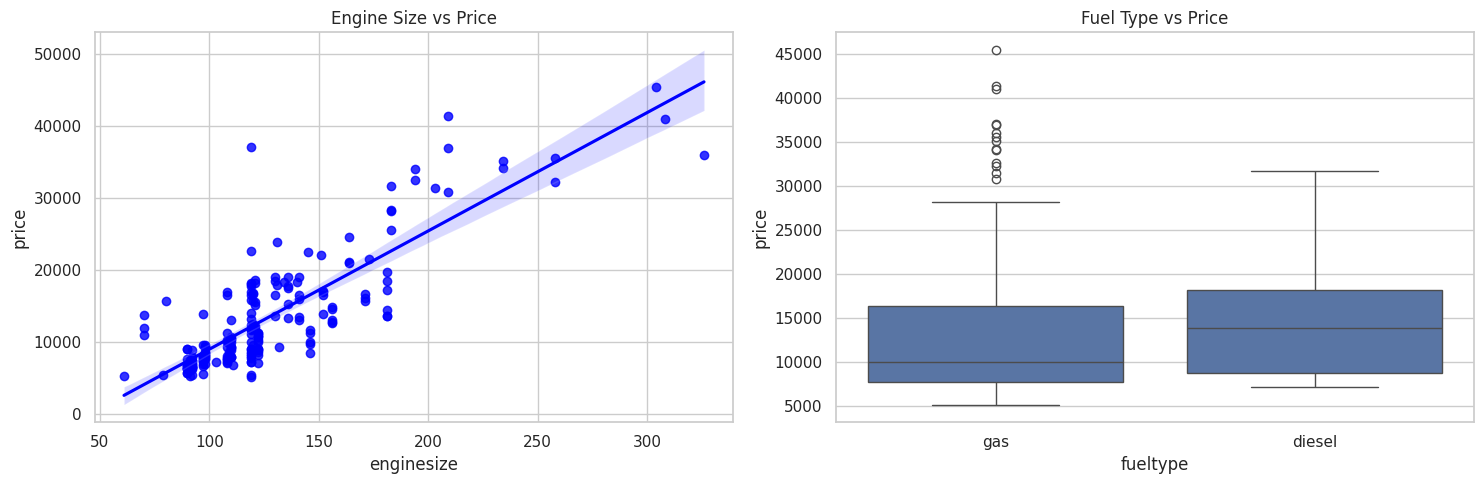

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.regplot(data=df, x='enginesize', y='price', color='blue')
plt.title('Engine Size vs Price')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='fueltype', y='price')
plt.title('Fuel Type vs Price')

plt.tight_layout()
plt.show()

In [8]:
## print your name in reverse here
reverse_name = name[::-1]

## 5. Encoding & Scaling
Converting categorical text to numbers and normalizing data.

In [9]:
# Binary Encoding
le = LabelEncoder()
binary_cols = ['fueltype', 'aspiration', 'doornumber', 'enginelocation']
for col in binary_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding for multi-category columns
df = pd.get_dummies(df, drop_first=True)

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
## concate your name and roll number here
concat_info = f"{name}_{roll_number}"
print(f"Concatenated Name and Roll Number: {concat_info}")

Concatenated Name and Roll Number: AMARA TARIQ_bsdsf23a007


## 6. Model Training & Metrics
Comparing a baseline model (Linear) with a high-performance model (Random Forest).

In [11]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    print(f"--- {name} Results ---")
    print(f"R2 Score: {r2_score(y_test, preds):.4f}")
    print(f"MAE: {mean_absolute_error(y_test, preds):.2f}\n")

--- Linear Regression Results ---
R2 Score: 0.9121
MAE: 1768.54

--- Random Forest Results ---
R2 Score: 0.9558
MAE: 1310.94

